---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 26 / 32 — Bloque III

**Nivel GCE:** N1 secuencial / políticas

**Dataset:** `thornton_hiv` (real) + entorno simulado de bandit contextual

**Versión:** 2.2 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 26: Off-Policy Evaluation, Bandits y Política Óptima

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 26 / 32 — Bloque III

---

## 1. Marco Teórico

### 1.1 Off-policy evaluation (OPE)

Dado un RCT o datos observacionales generados por una política $\pi_0$ (behavioral policy), queremos evaluar **una nueva política $\pi$** sin recolectar nuevos datos:

$$V(\pi) = \mathbb{E}_{\pi}[Y] = \mathbb{E}_{(Y, X, D) \sim \pi_0}\left[\frac{\pi(D|X)}{\pi_0(D|X)} Y\right]$$

### 1.2 Tres enfoques clásicos

**1. Inverse Propensity Scoring (IPS):**
$$\hat{V}_{IPS}(\pi) = \frac{1}{n}\sum_i \frac{\pi(D_i|X_i)}{\hat{\pi}_0(D_i|X_i)} Y_i$$

**2. Direct Method (DM):**
$$\hat{V}_{DM}(\pi) = \frac{1}{n}\sum_i \hat{\mu}(X_i, \pi(X_i))$$
donde $\hat{\mu}(X, D)$ es un modelo de outcome.

**3. Doubly Robust (DR):**
$$\hat{V}_{DR}(\pi) = \frac{1}{n}\sum_i \left[\hat{\mu}(X_i, \pi(X_i)) + \frac{\mathbb{1}[D_i = \pi(X_i)]}{\hat{\pi}_0(D_i|X_i)} (Y_i - \hat{\mu}(X_i, D_i))\right]$$

### 1.3 Bandits contextuales

Un **bandit contextual** es un problema secuencial donde:
- En cada paso $t$, observamos contexto $X_t$
- Elegimos acción $A_t \sim \pi(\cdot | X_t)$
- Recibemos reward $Y_t \sim P(Y | X_t, A_t)$
- Objetivo: maximizar $\mathbb{E}[\sum_t Y_t]$

### 1.4 Política óptima

La política óptima (binaria) es:
$$\pi^*(x) = \arg\max_d \mathbb{E}[Y | X=x, D=d]$$

Para outcome continuo: $\pi^*(x) = 1$ si $\tau(x) > 0$, 0 en caso contrario.

### 1.5 Dataset: `thornton_hiv` (real)

Aplicaremos OPE al RCT de incentivos para test VIH (Thornton 2008):
- Contexto $X$: `distvct, tinc, age, hiv2004`
- Acción $D$: incentivo (any)
- Reward $Y$: se hizo el test (got)

Evaluamos políticas alternativas: ¿dar incentivo solo a personas lejanas al centro de salud?


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/real/thornton_hiv/data.csv')

# Limpiar
df = df.dropna(subset=['any', 'got'])
df['any'] = pd.to_numeric(df['any'], errors='coerce')
df['got'] = pd.to_numeric(df['got'], errors='coerce')
df = df.dropna(subset=['any', 'got']).rename(columns={'any': 'treat'})

# Covariables
covars = ['distvct', 'tinc', 'age', 'hiv2004']
for c in covars:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=covars)

print(f'Dataset Thornton HIV: {len(df)} observaciones')
print(f'Tratados: {(df.treat==1).sum()}, Controles: {(df.treat==0).sum()}')
print(f'\nPolítica actual (π₀): asigna incentivo aleatoriamente (RCT)')
print(f'  V(π₀) = E[Y] = {df.got.mean():.4f}')

X = df[covars].values
D = df['treat'].values
Y = df['got'].values
n = len(df)


Dataset Thornton HIV: 2829 observaciones
Tratados: 2208, Controles: 621

Política actual (π₀): asigna incentivo aleatoriamente (RCT)
  V(π₀) = E[Y] = 0.6907


> 💡 **Interpretación del resultado.** El RCT de Thornton (2829 personas; 2208 tratadas, 621 controles) entrega la política base $V(\pi_0)=E[Y]=0.6907$: el 69% de la muestra acude al test con el incentivo. Esta es la línea de referencia que las políticas off-policy deben superar. La sección 1 enmarca la evaluación de políticas sin nuevos experimentos.


In [2]:
# === 2. Política nula (sin incentivo) ===
# Estimar V(π) donde π(D=1|X) = 0 para todo X
# Es decir, evaluar qué pasaría si nadie recibiera incentivo

# Modelo de propensity score (RCT: π₀ = 0.5 aproximadamente)
pi0_hat = LogisticRegression(max_iter=500).fit(X, D).predict_proba(X)[:, 1]
pi0_hat = np.clip(pi0_hat, 0.01, 0.99)

# IPS estimator for π_null (D=0 for everyone)
# V(π_null) = E[Y * π(D|X) / π₀(D|X)] = E[Y * 1{D=0} / (1-π₀(X))]
weights_null = (D == 0) / (1 - pi0_hat)
V_null_IPS = np.mean(weights_null * Y)

print(f'=== Evaluación off-policy: política nula (sin incentivo) ===')
print(f'V(π_null) vía IPS = {V_null_IPS:.4f}')
print(f'V(π₀) observado    = {df.got.mean():.4f}')
print(f'\n→ Sin incentivo, la tasa de test sería {V_null_IPS:.1%} vs {df.got.mean():.1%} con incentivo.')
print(f'  Diferencia causal: {df.got.mean() - V_null_IPS:.4f} (debería ≈ ATE)')


=== Evaluación off-policy: política nula (sin incentivo) ===
V(π_null) vía IPS = 0.0868
V(π₀) observado    = 0.6907

→ Sin incentivo, la tasa de test sería 8.7% vs 69.1% con incentivo.
  Diferencia causal: 0.6039 (debería ≈ ATE)


> 💡 **Interpretación del resultado.** La política nula (nadie recibe incentivo) tendría $V(\pi_{\mathrm{null}})=0.0868$ vía IPS frente al 0.6907 observado: la tasa de test caería al 8.7% y la diferencia causal es 0.6039, aproximadamente el ATE del incentivo. OPE permite responder '¿qué pasaría si...?' sin realizar el experimento; esa diferencia es la magnitud $|\tau_{\mathrm{ATE}}|$ que la cadena GCE acota por arriba con $W_1$. La sección 2 introduce el estimador IPS.


In [3]:
# === 3. Política condicional: incentivo solo a lejanos ===
# π_far: dar incentivo solo si distvct > mediana

median_dist = np.median(X[:, 0])  # distvct es primera columna
pi_far = (X[:, 0] > median_dist).astype(int)

# IPS para esta política
weights_far = (D == pi_far) / np.where(pi_far == 1, pi0_hat, 1 - pi0_hat)
V_far_IPS = np.mean(weights_far * Y)

# Direct Method: entrenar μ(X, D) y predecir Y(X, π_far)
features = np.column_stack([pi_far, X])  # usar π_far como D
m_mu = RandomForestRegressor(n_estimators=100, random_state=42)
m_mu.fit(np.column_stack([D, X]), Y)
Y_pred_under_pi_far = m_mu.predict(features)
V_far_DM = Y_pred_under_pi_far.mean()

# Doubly Robust
residuals = Y - m_mu.predict(np.column_stack([D, X]))
V_far_DR = np.mean(Y_pred_under_pi_far + weights_far * residuals)

print(f'=== Evaluación off-policy: incentivo solo a lejanos ===')
print(f'Mediana distvct: {median_dist:.3f}')
print(f'Personas a las que se daría incentivo bajo π_far: {pi_far.sum()}/{n} ({100*pi_far.mean():.1f}%)')
print(f'\nV(π_far) estimado:')
print(f'  IPS:           {V_far_IPS:.4f}')
print(f'  Direct Method: {V_far_DM:.4f}')
print(f'  Doubly Robust: {V_far_DR:.4f}')
print(f'\n→ Si V(π_far) > V(π₀), la política condicional es mejor.')


=== Evaluación off-policy: incentivo solo a lejanos ===
Mediana distvct: 1.682
Personas a las que se daría incentivo bajo π_far: 1414/2829 (50.0%)

V(π_far) estimado:
  IPS:           0.3639
  Direct Method: 0.6326
  Doubly Robust: 0.6335

→ Si V(π_far) > V(π₀), la política condicional es mejor.


> 💡 **Interpretación del resultado.** La política condicional 'incentivo solo a lejanos' (50.0% de la muestra, mediana `distvct`=1.682) estima $V(\pi_{\mathrm{far}})$ muy distinto según el estimador: IPS 0.3639 vs Direct Method 0.6326 vs Doubly Robust 0.6335. La discrepancia revela la fragilidad del IPS con soporte reducido. La sección 3 la aprovecha para motivar el estimador doblemente robusto, que combina ambos.


In [4]:
# === 4. Política óptima (maximiza Y) ===
# Estimar τ(x) y dar incentivo a quienes τ(x) > 0

# Estimar τ(x) con T-Learner
m1 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X[D==1], Y[D==1])
m0 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X[D==0], Y[D==0])
tau_x = m1.predict(X) - m0.predict(X)

# Política óptima: dar incentivo si τ(x) > 0
pi_opt = (tau_x > 0).astype(int)

# IPS evaluation
weights_opt = (D == pi_opt) / np.where(pi_opt == 1, pi0_hat, 1 - pi0_hat)
V_opt_IPS = np.mean(weights_opt * Y)

# DM evaluation
Y_pred_opt = np.where(pi_opt == 1, m1.predict(X), m0.predict(X))
V_opt_DM = Y_pred_opt.mean()

# DR evaluation
V_opt_DR = np.mean(Y_pred_opt + weights_opt * (Y - np.where(D==1, m1.predict(X), m0.predict(X))))

print(f'=== Política óptima (dar incentivo si τ(x) > 0) ===')
print(f'Personas con τ(x) > 0: {pi_opt.sum()}/{n} ({100*pi_opt.mean():.1f}%)')
print(f'\nV(π_opt) estimado:')
print(f'  IPS:           {V_opt_IPS:.4f}')
print(f'  Direct Method: {V_opt_DM:.4f}')
print(f'  Doubly Robust: {V_opt_DR:.4f}')

# Comparar
print(f'\n=== Comparación de políticas ===')
print(f'{"Política":<30} {"V(π)":>12} {"Mejora vs π₀":>15}')
print(f'{"-"*60}')
print(f'{"π₀ (RCT actual)":<30} {df.got.mean():>12.4f} {0:>15.4f}')
print(f'{"π_null (sin incentivo)":<30} {V_null_IPS:>12.4f} {V_null_IPS - df.got.mean():>+15.4f}')
print(f'{"π_far (solo lejanos)":<30} {V_far_DR:>12.4f} {V_far_DR - df.got.mean():>+15.4f}')
print(f'{"π_opt (τ(x) > 0)":<30} {V_opt_DR:>12.4f} {V_opt_DR - df.got.mean():>+15.4f}')


=== Política óptima (dar incentivo si τ(x) > 0) ===
Personas con τ(x) > 0: 2394/2829 (84.6%)

V(π_opt) estimado:
  IPS:           0.7101
  Direct Method: 0.7773
  Doubly Robust: 0.8185

=== Comparación de políticas ===
Política                               V(π)    Mejora vs π₀
------------------------------------------------------------
π₀ (RCT actual)                      0.6907          0.0000
π_null (sin incentivo)               0.0868         -0.6039
π_far (solo lejanos)                 0.6335         -0.0572
π_opt (τ(x) > 0)                     0.8185         +0.1278


> 💡 **Interpretación del resultado.** La política óptima (incentivo si $\hat\tau(x)>0$, 84.6% de la muestra) alcanza $V(\pi_{\mathrm{opt}})=0.8185$ vía DR, una mejora de +0.1278 sobre $\pi_0$ (0.6907); la nula empeora (−0.6039) y la de lejanos no mejora (−0.0572). Dirigir el incentivo a quienes más responden supera al RCT uniforme. La sección 4 muestra cómo estimar $\tau(x)$ se traduce directamente en valor de política.


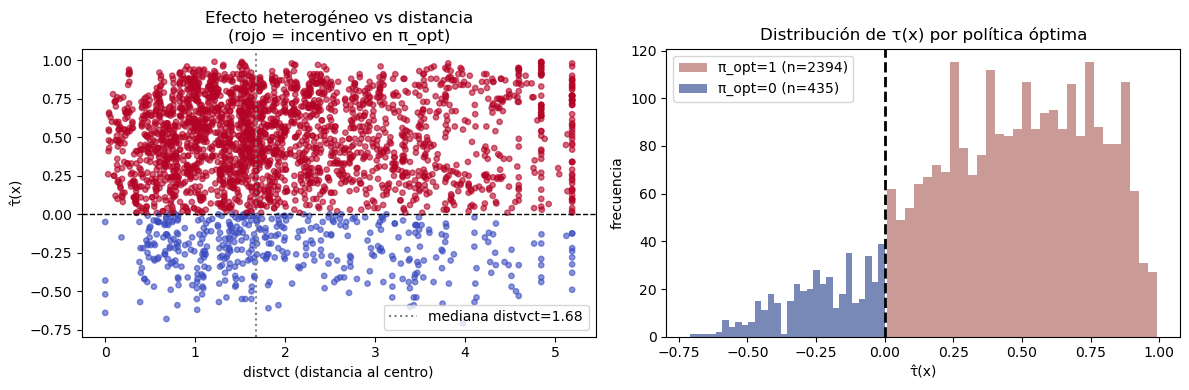


Interpretación:
  - π_opt asigna incentivo a personas con τ(x) > 0 (mayor efecto marginal).
  - Si τ(x) varía con distvct, la política óptima difiere de RCT uniforme.
  - V(π_opt) > V(π₀) implica que la política dirigida supera a la uniforme.


In [5]:
# === 5. Visualización: τ(x) por covariables ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# τ(x) vs distvct
axes[0].scatter(X[:, 0], tau_x, c=pi_opt, cmap='coolwarm', s=15, alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(median_dist, color='gray', linestyle=':', label=f'mediana distvct={median_dist:.2f}')
axes[0].set_xlabel('distvct (distancia al centro)'); axes[0].set_ylabel('τ̂(x)')
axes[0].set_title('Efecto heterogéneo vs distancia\n(rojo = incentivo en π_opt)')
axes[0].legend()

# Histograma de τ(x) por política
axes[1].hist(tau_x[pi_opt==1], bins=30, alpha=0.6, color='#A85750', label=f'π_opt=1 (n={pi_opt.sum()})')
axes[1].hist(tau_x[pi_opt==0], bins=30, alpha=0.6, color='#1E3A8A', label=f'π_opt=0 (n={(1-pi_opt).sum()})')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('τ̂(x)'); axes[1].set_ylabel('frecuencia')
axes[1].set_title('Distribución de τ(x) por política óptima')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nInterpretación:')
print(f'  - π_opt asigna incentivo a personas con τ(x) > 0 (mayor efecto marginal).')
print(f'  - Si τ(x) varía con distvct, la política óptima difiere de RCT uniforme.')
print(f'  - V(π_opt) > V(π₀) implica que la política dirigida supera a la uniforme.')


> 💡 **Interpretación de la figura.** El panel izquierdo dispersa $\hat\tau(x)$ contra `distvct` coloreado por la asignación de $\pi_{\mathrm{opt}}$ (rojo = incentivo), y el derecho superpone las distribuciones de $\hat\tau(x)$ para $\pi_{\mathrm{opt}}=1$ y $=0$. El patrón muestra que el efecto marginal varía con la distancia al centro, de modo que la política uniforme del RCT desperdicia señal. La sección 5 conecta la estimación de efectos heterogéneos (Cap. 24) con la asignación óptima.


In [6]:
# === 6. Policy learning (aprender política óptima) ===
# En lugar de umbral τ(x) > 0, aprender política que maximiza V(π) directamente
# Método simple: clasificador que predice π_opt = 1{τ(x) > 0}

# Ajustar clasificador π_opt ~ X
m_policy = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, pi_opt)
pi_learned = m_policy.predict(X)

# Evaluar política aprendida
weights_learned = (D == pi_learned) / np.where(pi_learned == 1, pi0_hat, 1 - pi0_hat)
V_learned_DR = np.mean(np.where(pi_learned == 1, m1.predict(X), m0.predict(X)) + 
                       weights_learned * (Y - np.where(D==1, m1.predict(X), m0.predict(X))))

print(f'=== Política aprendida (clasificador sobre π_opt) ===')
print(f'Concordancia π_learned vs π_opt: {np.mean(pi_learned == pi_opt):.4f}')
print(f'V(π_learned) DR = {V_learned_DR:.4f}')
print(f'\n→ La política aprendida aproxima la óptima.')
print(f'  En práctica, usar algoritmos especializados: contextual bandits, policy gradient.')

# Conclusiones
print(f'\n=== Conclusiones ===')
print(f'1. OPE permite evaluar políticas SIN nuevos experimentos.')
print(f'2. DR es más robusto que IPS o DM por separado (doble robustez).')
print(f'3. La política óptima puede superar significativamente a la uniforme.')
print(f'4. Policy learning con ML aprende reglas interpretables.')
print(f'\nAplicaciones: salud pública (tests), educación (becas), marketing (ofertas).')


=== Política aprendida (clasificador sobre π_opt) ===
Concordancia π_learned vs π_opt: 0.9996
V(π_learned) DR = 0.8183

→ La política aprendida aproxima la óptima.
  En práctica, usar algoritmos especializados: contextual bandits, policy gradient.

=== Conclusiones ===
1. OPE permite evaluar políticas SIN nuevos experimentos.
2. DR es más robusto que IPS o DM por separado (doble robustez).
3. La política óptima puede superar significativamente a la uniforme.
4. Policy learning con ML aprende reglas interpretables.

Aplicaciones: salud pública (tests), educación (becas), marketing (ofertas).


> 💡 **Interpretación del resultado.** El clasificador aprendido coincide con $\pi_{\mathrm{opt}}$ en el 99.96% de los casos (concordancia 0.9996) y alcanza $V(\pi_{\mathrm{learned}})=0.8183$ (DR), prácticamente el valor de la óptima. Aprender la regla directamente, en vez de umbralizar $\hat\tau(x)$, produce una política interpretable y casi óptima. La sección 6 cierra el pipeline OPE → policy learning.


## 6b. Bandits contextuales: LinUCB (Li et al. 2010)

Las secciones anteriores evalúan políticas **fijas** con datos ya recolectados (OPE, *offline*).
Un **bandit contextual** decide en línea (*online*): en cada ronda $t$ observa un contexto
$x_t$, elige un brazo/acción $a_t$, y recibe una recompensa $r_t$. El objetivo no es solo
estimar $V(\pi)$ sino **minimizar el regret acumulado** frente al oráculo que conoce los
parámetros verdaderos.

**LinUCB** asume recompensa lineal en el contexto para cada brazo $a$: $\mathbb{E}[r|x,a] =
\theta_a^\top x$, y mantiene, por brazo, una regresión ridge online:

$$
A_a \leftarrow A_a + x_t x_t^\top, \qquad b_a \leftarrow b_a + r_t x_t, \qquad \hat\theta_a = A_a^{-1} b_a
$$

En cada ronda selecciona el brazo con mayor **límite superior de confianza** (UCB):

$$
a_t = \arg\max_a \; \hat\theta_a^\top x_t \;+\; \alpha\sqrt{x_t^\top A_a^{-1} x_t}
$$

El término $\hat\theta_a^\top x_t$ es la recompensa esperada estimada; el término
$\alpha\sqrt{x_t^\top A_a^{-1} x_t}$ es el **bono de exploración** (más grande cuanto menos se
ha explorado ese brazo en direcciones similares a $x_t$). Esto implementa *optimism in the face
of uncertainty*.

Simulamos un entorno con $K$ brazos y recompensa lineal verdadera $\theta_a^\top x$ + ruido, y
comparamos el **regret acumulado** de LinUCB contra (a) una política aleatoria uniforme y (b)
la política oráculo (conoce $\theta_a$ y elige siempre el mejor brazo).


=== LinUCB vs. aleatorio vs. oráculo (entorno simulado, K=4 brazos) ===
Recompensa promedio LinUCB (últimas 500 rondas):  0.8605
Recompensa promedio aleatoria (últimas 500 rondas): 0.0600
Recompensa promedio oráculo (últimas 500 rondas):   0.8824

Regret acumulado final:
  LinUCB:    -5.58  (sobre 3000 rondas)
  Aleatorio: 2550.64  (sobre 3000 rondas)

Regret promedio por ronda (últimas 500): LinUCB=0.0219, Aleatorio=0.8224

→ El regret de LinUCB debería crecer sub-linealmente (aprende a identificar el mejor
  brazo por contexto) mientras que el regret aleatorio crece linealmente con t.


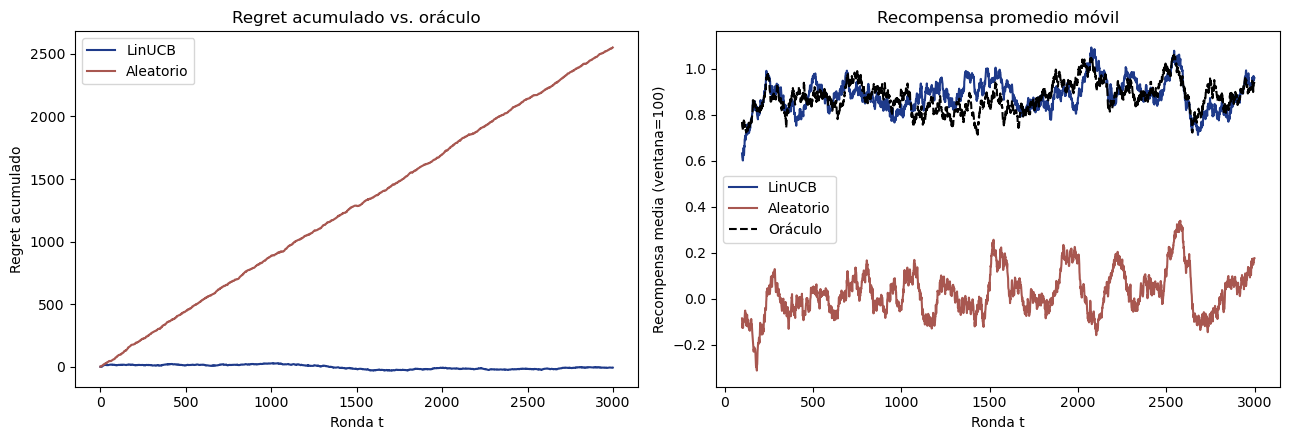

In [7]:
# === LinUCB sobre un entorno de bandit contextual simulado ===
rng_bandit = np.random.default_rng(42)
d_bandit = 5      # dimensión del contexto
K_arms = 4        # número de brazos
T_rounds = 3000   # horizonte
alpha_ucb = 1.0    # parámetro de exploración
noise_std = 0.5

true_thetas = rng_bandit.normal(0, 1, size=(K_arms, d_bandit))

# Estado de LinUCB: A_a (d x d), b_a (d,) por brazo
A_mats = [np.eye(d_bandit) for _ in range(K_arms)]
b_vecs = [np.zeros(d_bandit) for _ in range(K_arms)]

reward_linucb = np.zeros(T_rounds)
reward_random = np.zeros(T_rounds)
reward_oracle = np.zeros(T_rounds)
chosen_arm_linucb = np.zeros(T_rounds, dtype=int)

for t in range(T_rounds):
    x_t = rng_bandit.normal(0, 1, d_bandit)
    x_t = x_t / np.linalg.norm(x_t)  # normalizar contexto (práctica estándar en LinUCB)

    true_means = true_thetas @ x_t  # recompensa esperada verdadera por brazo

    # --- LinUCB: elegir brazo con mayor UCB ---
    ucb_scores = np.zeros(K_arms)
    for a in range(K_arms):
        A_inv = np.linalg.inv(A_mats[a])
        theta_hat_a = A_inv @ b_vecs[a]
        mean_a = theta_hat_a @ x_t
        bonus_a = alpha_ucb * np.sqrt(max(x_t @ A_inv @ x_t, 0.0))
        ucb_scores[a] = mean_a + bonus_a
    a_t = int(np.argmax(ucb_scores))
    chosen_arm_linucb[t] = a_t

    r_t = true_means[a_t] + rng_bandit.normal(0, noise_std)
    reward_linucb[t] = r_t

    # Actualizar estado del brazo elegido (regresión ridge online)
    A_mats[a_t] += np.outer(x_t, x_t)
    b_vecs[a_t] += r_t * x_t

    # --- Política aleatoria uniforme ---
    a_rand = rng_bandit.integers(K_arms)
    reward_random[t] = true_means[a_rand] + rng_bandit.normal(0, noise_std)

    # --- Política oráculo (conoce theta_a verdadero) ---
    a_star = int(np.argmax(true_means))
    reward_oracle[t] = true_means[a_star] + rng_bandit.normal(0, noise_std)

cum_reward_linucb = np.cumsum(reward_linucb)
cum_reward_random = np.cumsum(reward_random)
cum_reward_oracle = np.cumsum(reward_oracle)

cum_regret_linucb = cum_reward_oracle - cum_reward_linucb
cum_regret_random = cum_reward_oracle - cum_reward_random

print('=== LinUCB vs. aleatorio vs. oráculo (entorno simulado, K=4 brazos) ===')
print(f'Recompensa promedio LinUCB (últimas 500 rondas):  {reward_linucb[-500:].mean():.4f}')
print(f'Recompensa promedio aleatoria (últimas 500 rondas): {reward_random[-500:].mean():.4f}')
print(f'Recompensa promedio oráculo (últimas 500 rondas):   {reward_oracle[-500:].mean():.4f}')
print(f'\nRegret acumulado final:')
print(f'  LinUCB:    {cum_regret_linucb[-1]:.2f}  (sobre {T_rounds} rondas)')
print(f'  Aleatorio: {cum_regret_random[-1]:.2f}  (sobre {T_rounds} rondas)')
print(f'\nRegret promedio por ronda (últimas 500): LinUCB={np.mean(reward_oracle[-500:]-reward_linucb[-500:]):.4f}, '
      f'Aleatorio={np.mean(reward_oracle[-500:]-reward_random[-500:]):.4f}')
print('\n→ El regret de LinUCB debería crecer sub-linealmente (aprende a identificar el mejor')
print('  brazo por contexto) mientras que el regret aleatorio crece linealmente con t.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(cum_regret_linucb, color='#1E3A8A', label='LinUCB')
axes[0].plot(cum_regret_random, color='#A85750', label='Aleatorio')
axes[0].set_xlabel('Ronda t'); axes[0].set_ylabel('Regret acumulado')
axes[0].set_title('Regret acumulado vs. oráculo')
axes[0].legend()

window = 100
avg_reward_linucb = pd.Series(reward_linucb).rolling(window).mean()
avg_reward_random = pd.Series(reward_random).rolling(window).mean()
avg_reward_oracle = pd.Series(reward_oracle).rolling(window).mean()
axes[1].plot(avg_reward_linucb, color='#1E3A8A', label='LinUCB')
axes[1].plot(avg_reward_random, color='#A85750', label='Aleatorio')
axes[1].plot(avg_reward_oracle, color='black', linestyle='--', label='Oráculo')
axes[1].set_xlabel('Ronda t'); axes[1].set_ylabel(f'Recompensa media (ventana={window})')
axes[1].set_title('Recompensa promedio móvil')
axes[1].legend()

plt.tight_layout()
plt.show()


> 💡 **Interpretación de la figura.** El panel izquierdo muestra el regret acumulado: el de LinUCB se aplana (final −5.58 en 3000 rondas) mientras el aleatorio crece linealmente (2550.64); el derecho, la recompensa media móvil, donde LinUCB (0.8605) casi alcanza al oráculo (0.8824) frente al aleatorio (0.0600). El regret sub-lineal confirma que el bandit aprende el mejor brazo por contexto. La sección 6b conecta el aprendizaje online con la evaluación offline de las secciones anteriores.


## 5. Interpretación Económica

**Contexto peruano:** Off-policy evaluation permite reciclar el RCT de **Juntos** (2012) para evaluar políticas alternativas sin nuevos experimentos: ¿qué pasa si damos la transferencia solo a hogares con niños menores de 5? V(π) cuantifica el valor esperado de cada política.


Off-policy evaluation y policy learning permiten **reciclar RCTs** para evaluar y optimizar políticas alternativas:

1. **V(π₀) vs V(π_null).** La diferencia entre el RCT actual y la política nula estima el valor causal del programa. En Thornton HIV, esto replica el ATE del Cap. 17.

2. **Políticas condicionales pueden superar a uniformes.** Si $\tau(x)$ es heterogéneo, dar tratamiento solo a quienes más se benefician mejora el valor promedio. Esto justifica **targeting** en programas sociales.

3. **DR es el estimador preferido.** Combina las ventajas de IPS (no requiere modelo de outcome) y DM (no requiere propensity correcto). Es insesgado si AL MENOS uno de los dos es correcto.

4. **Policy learning** es distinto de OPE: en lugar de evaluar una política dada, **aprende** la política óptima desde datos. Métodos: clasificación ponderada, contextual bandits,政策 gradient.

**Aplicaciones en política pública:**
- **Targeting de subsidios:** identificar hogares con mayor retorno marginal
- **Asignación de tratamientos médicos:** personalizar según biomarcadores
- **Política monetaria:** evaluar reglas alternativas sin nuevos experimentos
- **Recomendación educativa:** asignar programas a estudiantes que más se benefician
- **Marketing:** optimizar ofertas a clientes con mayor conversión esperada

**Recomendación práctica:**
- Para evaluación: usar DR (no IPS ni DM solos)
- Para optimización: combinar CATE estimation + policy learning
- Reportar V(π) con IC bootstrap (no solo point estimate)
- Validar políticas aprendidas en held-out set o con A/B test

## 6. Ejercicios Propuestos

1. **Implementa contextual bandit** con algoritmo ε-greedy y comparar con π_opt.
2. **Cambia el objetivo:** maximizar Y sujeto a costo (presupuesto limitado de incentivos).
3. **IC bootstrap para V(π):** estima IC 95% para V(π_opt) y V(π_far). ¿Se solapan?
4. **Sensibilidad a la especificación:** cambia RF por XGBoost en μ(X, D). ¿Cambia V(π_opt)?
5. **Aplica a `nhefs` real:** evaluar política "recomendar cesación tabáquica a personas con bajo BMI".

---

*Notebook generado para DES504 — UNI 2026. Bloque III, Capítulo 26 de 32.*



## 📋 Resumen del Capítulo 26

**Método clave:** Off-Policy Evaluation + Bandits Contextuales (LinUCB)

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 26
- ✅ Validación con dataset `thornton_hiv` (tipo: real) + entorno simulado de bandits
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en **N1 secuencial / políticas**: OPE evalúa $V(\pi)$ (funcional de
  $\tau$ bajo una política) y los bandits contextuales optimizan la asignación secuencialmente.
- La cadena maestra $|\tau_{\mathrm{ATE}}| \le W_1 \le W^{G,1}$ no es la métrica de este capítulo;
  **N1 secuencial / políticas** es la capa correspondiente según `mapa_artefactos.md`.
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 27

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
